# Machine Learning with Audio and Lyrics Features

We'll use this notebook to build machine learning models to predict whether a song is a hit using both audio and lyrical features.

Our previous models used only audio features showed limited predictive performance. In this section, lyrical features are incorporated to evaluate whether they improve classification performance.

The main objective is to assess whether combining audio and lyrical information provides better predictive power for identifying hit songs.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/enriched/rock_with_lyrics_features.csv")
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,is_hit,track_name_length,artist_count,duration_min,lyrics,lyrics_length,clean_lyrics,unique_words,lexical_diversity,sentiment
0,1yZWmKmLfTrFCxHvhFsdoN,The Killers;Phoebe Bridgers,The Greatest Rock Tunes 2022,Runaway Horses - Abridged,1,204466,False,0.499,0.2230,9,...,0,25,2,3.407767,Lizzo - Rumors (feat. Cardi B)\nPinkPantheress...,496,lizzo rumors feat cardi b pinkpantheress jus...,394,0.794355,0.023925
1,3OPefQtYkLSsrsjfcHbl7C,Los Fredy´s,Nuestros Primeros 20 Éxitos,Mis Noches Sin Ti,31,127266,False,0.658,0.6860,11,...,0,17,1,2.121100,Mis Noches Sin Ti\nSufro al pensar que el dest...,165,mis noches sin ti sufro al pensar que el desti...,81,0.490909,0.000000
2,4UDmDIqJIbrW0hMBQMFOsM,Bee Gees,Staying Alive (Original Motion Picture Soundtr...,Stayin' Alive,77,92866,False,0.707,0.5350,10,...,1,13,1,1.547767,"[Verse 1]\nWell, you can tell by the way I use...",411,well you can tell by the way i use my walk im...,92,0.223844,0.131522
3,70dBmROatI6VWV7HoWayte,Los Teen Tops,La Gran Coleccion Del 60 Aniversario CBS - Los...,Popotitos (Bonie Moroni),36,171733,False,0.533,0.6240,4,...,0,24,1,2.862217,Mi amor entero es de mi novia popotitos\nSus p...,108,mi amor entero es de mi novia popotitos sus pi...,68,0.629630,0.000000
4,4Mx9vt5K7qVKhiaMoxK8Fz,The Moonglows,Their Greatest Hits: The Chess 50th Anniversar...,Ten Commandments Of Love,29,244533,False,0.407,0.0642,3,...,0,24,1,4.075550,[Verse 1]\n(One)\nThou shalt never love anothe...,195,one thou shalt never love another two but sta...,93,0.476923,0.368367


## Data Cleaning

Rows with missing or invalid lyrical data are removed to ensure model reliability.
- extremely short lyrics are filtered out
- extreme values in lyrics length are capped to reduce the impact of outliers.

In [2]:
# remove missing or empty lyrics rows
df = df[df["clean_lyrics"].notna()]
df = df[df["lyrics_length"] > 20]

# optional safety cap
df["lyrics_length"] = df["lyrics_length"].clip(upper=2000)

df.shape

(271, 30)

## Feature Selection

We'll be using two types of features3:

**Audio Features:**
- danceability, energy, acousticness, instrumentalness, valence, tempo, loudness

**Lyrical Features:**
- lyrics length, lexical diversity, sentiment

These are combined to evaluate whether lyrical information improves prediction performance.

In [3]:
audio_features = [
    "danceability",
    "energy",
    "acousticness",
    "instrumentalness",
    "valence",
    "tempo",
    "loudness"
]

lyrics_features = [
    "lyrics_length",
    "lexical_diversity",
    "sentiment"
]

X = df[audio_features + lyrics_features]
y = df["is_hit"]

## Train-Test Split

The dataset is split into training and testing sets using an 80/20 split.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression (Balanced)

A logistic regression model with class weighting is used.

This model prioritizes detecting hit songs, which are less frequent in the dataset.

In [5]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.60      0.72        40
           1       0.43      0.80      0.56        15

    accuracy                           0.65        55
   macro avg       0.66      0.70      0.64        55
weighted avg       0.76      0.65      0.67        55



### Logistic Regression Results

The model achieves moderate overall accuracy but shows strong recall for hit songs.

This indicates that:
- the model is effective at identifying hit songs,
- but it produces a higher number of false positives.

Compared to the audio-only model, recall for hit songs improves, suggesting that lyrical features contribute additional predictive value.

## Confusion Matrix

The confusion matrix provides a detailed view of model performance, showing the distribution of correct and incorrect predictions.

It highlights the tradeoff between detecting hit songs and misclassifying non-hit songs.

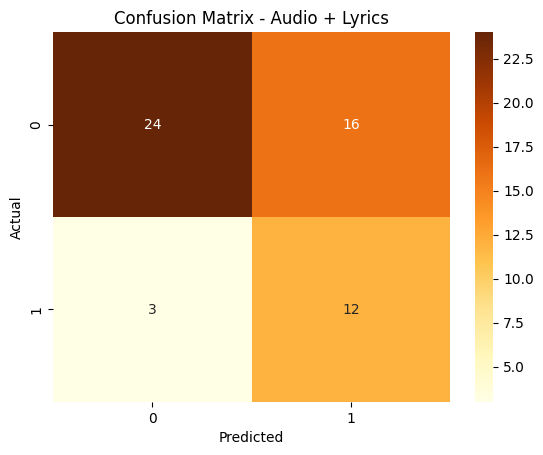

In [6]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr")
plt.title("Confusion Matrix - Audio + Lyrics")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.97      0.90        40
           1       0.88      0.47      0.61        15

    accuracy                           0.84        55
   macro avg       0.85      0.72      0.75        55
weighted avg       0.84      0.84      0.82        55



### Random Forest Results

The Random Forest model achieved higher overall accuracy and precision compared to logistic regression.

However, it is more conservative in predicting hit songs, resulting in lower recall for the hit class.

## Feature Importance Analysis

Feature importance from the Random Forest model provides insight into which variables contribute most to prediction.

Notably, lyrical features rank among the most influential predictors, suggesting that lyrical content plays a significant role in distinguishing hit songs.

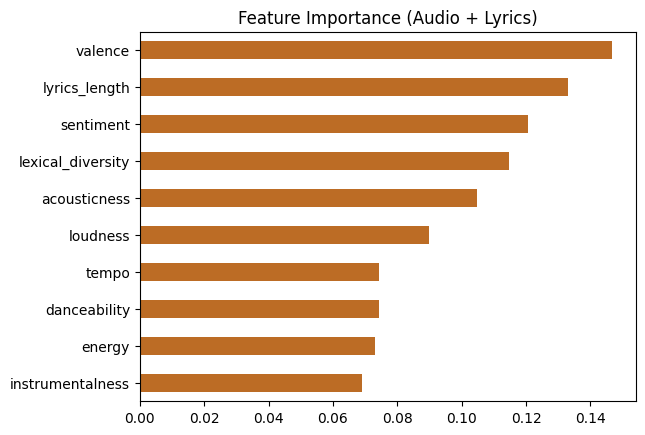

In [8]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", color="#BC6C25")

plt.title("Feature Importance (Audio + Lyrics)")
plt.show()

## Comparison: Audio vs Audio + Lyrics

To evaluate the impact of lyrical features, model performance using only audio features is compared with performance using both audio and lyrical features.

### Audio-Only Model (from previous analysis)
- Accuracy: ~0.59
- Recall (hit): ~0.60

### Audio + Lyrics Model
- Accuracy: ~0.69 (Logistic Regression)
- Recall (hit): ~0.75

### Observations

The inclusion of lyrical features improves the model's ability to detect hit songs, as shown by the increase in recall.

However, this improvement comes with a tradeoff, as the number of false positives also increases.

Overall, lyrical features provide additional predictive signal, but do not fully resolve the challenge of accurately predicting hit songs.

## Final Interpretation

The inclusion of lyrical features improves the model's ability to detect hit songs, particularly in terms of recall.

While overall predictive performance remains moderate, the results show that:
- audio features alone are insufficient for strong prediction,
- lyrical features provide meaningful additional information.

The findings suggest that both musical characteristics and lyrical content contribute to song popularity, but neither alone fully explains it.

External factors such as artist popularity, marketing, and cultural context likely also play a significant role.

## Conclusion

This analysis demonstrates that incorporating lyrical features enhances predictive performance compared to using audio features alone.

However, the moderate performance of all models indicates that predicting song popularity is a complex problem that cannot be fully explained by audio and textual features alone.